# 02 EDA Additional

## 1. Data

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
ROOT = Path.cwd().resolve().parent

HEALTH_RISK_PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_cycle3_health_risk_processed_only.csv"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ------------------------------------------------------------
# Load processed-only health-risk data
# ------------------------------------------------------------
health_risk = pd.read_csv(HEALTH_RISK_PROCESSED_PATH)

required_cols = [
    "sad_binary",
    "sad_group",
    "smoker_binary",
    "alcohol_binary",
    "marijuana_binary",
    "health_risk_behavior_count"
]

missing_cols = [col for col in required_cols if col not in health_risk.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Please rerun 01_DataCheck.ipynb first.")

print("Rows valid for health-risk extension:", len(health_risk))

Rows valid for health-risk extension: 12037


## 2. Health-risk Behavior Count Summary

In [2]:
health_risk_summary = (
    health_risk
    .groupby(["sad_binary", "sad_group"], as_index=False)
    .agg(
        n=("health_risk_behavior_count", "count"),
        mean_health_risk_count=("health_risk_behavior_count", "mean"),
        median_health_risk_count=("health_risk_behavior_count", "median")
    )
)

health_risk_summary = health_risk_summary.sort_values(
    "sad_binary",
    ascending=False
).reset_index(drop=True)

health_risk_summary.to_csv(
    TAB_DIR / "02_health_risk_behavior_count_summary_by_sad_group.csv",
    index=False
)

display(health_risk_summary)

,sad_binary,sad_group,n,mean_health_risk_count,median_health_risk_count
0,1,Sad/Hopeless: Yes,3463,1.0907,1.0000
1,0,Sad/Hopeless: No,8574,0.7182,0.0000


#### **Interpretation**

The **Sad/Hopeless: Yes** group had a higher mean health-risk behavior count than the **Sad/Hopeless: No** group.

This suggests that students who felt sad or hopeless tended to report more substance-related health-risk behaviors overall.

## 3. Create Behavior Combination Categories

In [3]:
# ------------------------------------------------------------
# Create combination labels
# ------------------------------------------------------------
def make_combination_label(row):
    behaviors = []

    if row["smoker_binary"] == 1:
        behaviors.append("Cigarette")
    if row["alcohol_binary"] == 1:
        behaviors.append("Alcohol")
    if row["marijuana_binary"] == 1:
        behaviors.append("Marijuana")

    if len(behaviors) == 0:
        return "None"
    if len(behaviors) == 1:
        return f"{behaviors[0]} only"
    if len(behaviors) == 3:
        return "All three"
    return " + ".join(behaviors)

health_risk["behavior_combination"] = health_risk.apply(make_combination_label, axis=1)

combination_order = [
    "None",
    "Cigarette only",
    "Alcohol only",
    "Marijuana only",
    "Cigarette + Alcohol",
    "Cigarette + Marijuana",
    "Alcohol + Marijuana",
    "All three"
]

combination_counts = (
    pd.crosstab(
        health_risk["behavior_combination"],
        health_risk["sad_group"]
    )
    .reindex(combination_order, fill_value=0)
)

combination_props = (
    pd.crosstab(
        health_risk["behavior_combination"],
        health_risk["sad_group"],
        normalize="columns"
    )
    .reindex(combination_order, fill_value=0) * 100
)

combination_table = pd.DataFrame({
    "behavior_combination": combination_order,
    "no_count": combination_counts["Sad/Hopeless: No"].values,
    "no_percent": combination_props["Sad/Hopeless: No"].round(1).values,
    "yes_count": combination_counts["Sad/Hopeless: Yes"].values,
    "yes_percent": combination_props["Sad/Hopeless: Yes"].round(1).values,
})

combination_table.to_csv(
    TAB_DIR / "02_health_risk_behavior_combination_table.csv",
    index=False
)

display(combination_table)

,behavior_combination,no_count,no_percent,yes_count,yes_percent
0,None,4828,56.3000,1362,39.3000
1,Cigarette only,126,1.5000,67,1.9000
2,Alcohol only,1758,20.5000,826,23.9000
3,Marijuana only,147,1.7000,73,2.1000
4,Cigarette + Alcohol,456,5.3000,297,8.6000
5,Cigarette + Marijuana,60,0.7000,40,1.2000
6,Alcohol + Marijuana,502,5.9000,257,7.4000
7,All three,697,8.1000,541,15.6000


#### **Interpretation**

This table shows the exact behavior combinations behind the health-risk behavior count.

The **Sad/Hopeless: Yes** group had a lower percentage of students with **no substance-related risk behaviors** and a higher percentage of students who reported **all three behaviors**.

## 4. UpSet-style Combination Plot

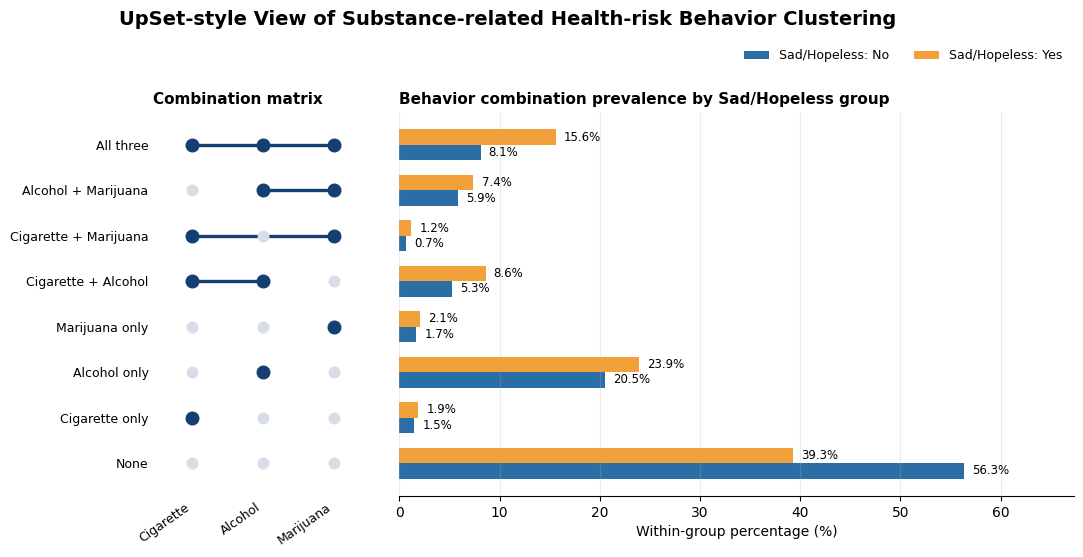

In [4]:
# ------------------------------------------------------------
# UpSet-style combination plot
# ------------------------------------------------------------
plot_order = [
    "All three",
    "Alcohol + Marijuana",
    "Cigarette + Marijuana",
    "Cigarette + Alcohol",
    "Marijuana only",
    "Alcohol only",
    "Cigarette only",
    "None"
]

plot_df = (
    combination_table
    .set_index("behavior_combination")
    .loc[plot_order]
    .reset_index()
)

behavior_cols = ["Cigarette", "Alcohol", "Marijuana"]

def combination_members(label):
    if label == "None":
        return []
    if label == "All three":
        return behavior_cols
    return [part.replace(" only", "") for part in label.split(" + ")]

# Colors
color_no = "#2b6ea6"
color_yes = "#f2a13a"
gray = "#d8dee7"
dark = "#143f72"

fig = plt.figure(figsize=(11.8, 6.0))

gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[1.25, 3.85],
    wspace=0.06
)

ax_matrix = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1], sharey=ax_matrix)

y = np.arange(len(plot_df))
bar_h = 0.34

# ------------------------------------------------------------
# Matrix panel
# ------------------------------------------------------------
for i, label in enumerate(plot_df["behavior_combination"]):
    members = combination_members(label)
    xs_present = []

    for j, behavior in enumerate(behavior_cols):
        is_present = behavior in members

        ax_matrix.scatter(
            j,
            i,
            s=82 if is_present else 58,
            color=dark if is_present else gray,
            zorder=3
        )

        if is_present:
            xs_present.append(j)

    if len(xs_present) >= 2:
        ax_matrix.plot(
            [min(xs_present), max(xs_present)],
            [i, i],
            color=dark,
            linewidth=2.4,
            zorder=2
        )

ax_matrix.set_xticks(range(len(behavior_cols)))
ax_matrix.set_xticklabels(
    behavior_cols,
    rotation=35,
    ha="right",
    fontsize=9
)

ax_matrix.set_yticks(y)
ax_matrix.set_yticklabels(plot_df["behavior_combination"], fontsize=9)

ax_matrix.invert_yaxis()
ax_matrix.set_xlim(-0.55, len(behavior_cols) - 0.45)
ax_matrix.set_title(
    "Combination matrix",
    loc="left",
    fontsize=11,
    fontweight="bold"
)

ax_matrix.tick_params(axis="y", length=0)
ax_matrix.tick_params(axis="x", length=0)

for spine in ax_matrix.spines.values():
    spine.set_visible(False)

# ------------------------------------------------------------
# Paired horizontal bar panel
# ------------------------------------------------------------
ax_bar.barh(
    y + bar_h / 2,
    plot_df["no_percent"],
    height=bar_h,
    color=color_no,
    label="Sad/Hopeless: No"
)

ax_bar.barh(
    y - bar_h / 2,
    plot_df["yes_percent"],
    height=bar_h,
    color=color_yes,
    label="Sad/Hopeless: Yes"
)

# Show labels for all non-zero percentages
for i, row in plot_df.iterrows():
    no_val = row["no_percent"]
    yes_val = row["yes_percent"]

    if no_val > 0:
        ax_bar.text(
            no_val + 0.8,
            i + bar_h / 2,
            f"{no_val:.1f}%",
            va="center",
            fontsize=8.5
        )

    if yes_val > 0:
        ax_bar.text(
            yes_val + 0.8,
            i - bar_h / 2,
            f"{yes_val:.1f}%",
            va="center",
            fontsize=8.5
        )

ax_bar.set_xlabel("Within-group percentage (%)", fontsize=10)

ax_bar.set_title(
    "Behavior combination prevalence by Sad/Hopeless group",
    loc="left",
    fontsize=11,
    fontweight="bold"
)

xmax = max(plot_df["no_percent"].max(), plot_df["yes_percent"].max())
ax_bar.set_xlim(0, xmax + 11)

ax_bar.grid(axis="x", alpha=0.25)
ax_bar.tick_params(axis="y", left=False, labelleft=False)

# Move legend above the bar panel
ax_bar.legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 1.10),
    ncol=2,
    frameon=False,
    fontsize=9
)

for spine in ["top", "right", "left"]:
    ax_bar.spines[spine].set_visible(False)

# ------------------------------------------------------------
# Title and layout adjustment
# ------------------------------------------------------------
fig.suptitle(
    "UpSet-style View of Substance-related Health-risk Behavior Clustering",
    fontsize=14,
    fontweight="bold",
    y=0.97
)

# Manual adjustment instead of tight_layout
fig.subplots_adjust(
    left=0.20,
    right=0.98,
    bottom=0.16,
    top=0.80,
    wspace=0.06
)

fig.savefig(
    FIG_DIR / "02_upset_style_health_risk_behavior_combinations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### **Interpretation**

The UpSet-style plot shows that the **Sad/Hopeless: Yes** group had a smaller share of students with **no substance-related risk behaviors** and a larger share of students reporting **all three behaviors**.

This supports the idea that substance-related health-risk behaviors appear to cluster more strongly among students who felt sad or hopeless.

## 5. Multiple-risk Threshold Summary

In [5]:
# ------------------------------------------------------------
# 2+ behavior threshold summary
# ------------------------------------------------------------
threshold_summary = (
    health_risk
    .assign(two_or_more_behaviors=health_risk["health_risk_behavior_count"] >= 2)
    .groupby(["sad_binary", "sad_group"], as_index=False)
    .agg(
        n=("two_or_more_behaviors", "count"),
        two_or_more_count=("two_or_more_behaviors", "sum"),
        two_or_more_percent=("two_or_more_behaviors", "mean")
    )
)

threshold_summary["two_or_more_percent"] = threshold_summary["two_or_more_percent"] * 100
threshold_summary = threshold_summary.sort_values("sad_binary", ascending=False).reset_index(drop=True)

threshold_summary.to_csv(
    TAB_DIR / "02_health_risk_two_or_more_summary_by_sad_group.csv",
    index=False
)

display(threshold_summary)

,sad_binary,sad_group,n,two_or_more_count,two_or_more_percent
0,1,Sad/Hopeless: Yes,3463,1135,32.7751
1,0,Sad/Hopeless: No,8574,1715,20.0023


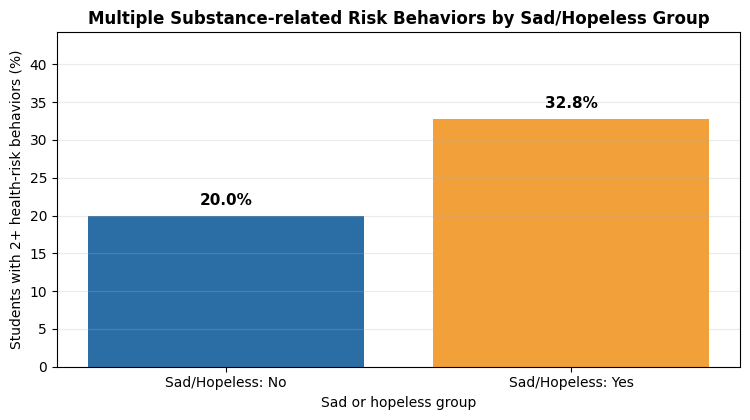

In [6]:
# ------------------------------------------------------------
# 2+ behavior threshold bar chart
# ------------------------------------------------------------
plot_threshold = threshold_summary.copy()
plot_threshold["sad_group"] = pd.Categorical(
    plot_threshold["sad_group"],
    categories=["Sad/Hopeless: No", "Sad/Hopeless: Yes"],
    ordered=True
)
plot_threshold = plot_threshold.sort_values("sad_group")

fig, ax = plt.subplots(figsize=(7.6, 4.3))

bars = ax.bar(
    plot_threshold["sad_group"].astype(str),
    plot_threshold["two_or_more_percent"],
    color=["#2b6ea6", "#f2a13a"]
)

ax.set_ylabel("Students with 2+ health-risk behaviors (%)")
ax.set_xlabel("Sad or hopeless group")
ax.set_title("Multiple Substance-related Risk Behaviors by Sad/Hopeless Group", fontweight="bold")
ax.set_ylim(0, plot_threshold["two_or_more_percent"].max() * 1.35)
ax.grid(axis="y", alpha=0.25)

for bar, val in zip(bars, plot_threshold["two_or_more_percent"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

fig.savefig(
    FIG_DIR / "02_health_risk_two_or_more_bar_by_sad_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### **Interpretation**

The **Sad/Hopeless: Yes** group had a higher percentage of students reporting **two or more** substance-related health-risk behaviors.

This provides a simple summary of the clustering pattern shown in the UpSet-style combination plot.